# Ensemble Learning-Method 2

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from keras.utils import to_categorical

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout


### Data processing

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define dataset paths
train_data_dir = "Dataset_2_sample/train_n"
test_data_dir = "Dataset_2_sample/test_n"

# Define image dimensions
image_height, image_width = 224, 224  # Adjust these dimensions as needed

# Define batch size
batch_size = 16  # Adjust as needed

# Create data generators for training and testing
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,  # Normalize pixel values to [0, 1]
    rotation_range=20,  # Data augmentation options (adjust as needed)
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)  # Only rescale for testing data


In [9]:
# Create training and testing data generators
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  
    shuffle=True
)


Found 410 images belonging to 2 classes.


In [10]:
test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical', 
    shuffle=False  # Set to False for consistent evaluation
)

Found 62 images belonging to 2 classes.


## Ensemble part

In [34]:
from keras.models import load_model
from sklearn.metrics import accuracy_score
#loading models
model1 = load_model('saved_models/model1.hdf5')
model2 = load_model('saved_models/model2.hdf5')
model3 = load_model('saved_models/model3.hdf5')

models = [model1, model2, model3]

OSError: No file or directory found at saved_models/model1.hdf5

In [ ]:
#Weighted average ensemble
models = [model1, model2, model3]
preds = [model.predict(X_test) for model in models]
preds=np.array(preds)
weights = [0.4, 0.2, 0.4]

In [ ]:
#Using tensordot to sum the products of all elements over specified axes.
weighted_preds = np.tensordot(preds, weights, axes=((0),(0)))
weighted_ensemble_prediction = np.argmax(weighted_preds, axis=1)

weighted_accuracy = accuracy_score(y_test, weighted_ensemble_prediction)

print('Accuracy Score for model1 = ', accuracy1)
print('Accuracy Score for model2 = ', accuracy2)
print('Accuracy Score for model3 = ', accuracy3)
print('Accuracy Score for average ensemble = ', ensemble_accuracy)
print('Accuracy Score for weighted average ensemble = ', weighted_accuracy)

### Searching for best weight

In [ ]:
#Grid search for the best combination of w1, w2, w3 that gives maximum acuracy
models = [model1, model2, model3]
preds1 = [model.predict(X_test) for model in models]
preds1=np.array(preds1)

import pandas as pd
df = pd.DataFrame([])

for w1 in range(0, 5):
    for w2 in range(0,5):
        for w3 in range(0,5):
            wts = [w1/10.,w2/10.,w3/10.]
            wted_preds1 = np.tensordot(preds1, wts, axes=((0),(0)))
            wted_ensemble_pred = np.argmax(wted_preds1, axis=1)
            weighted_accuracy = accuracy_score(y_test, wted_ensemble_pred)
            df = df.append(pd.DataFrame({'wt1':wts[0],'wt2':wts[1], 
                                         'wt3':wts[2], 'acc':weighted_accuracy*100}, index=[0]), ignore_index=True)
            
max_acc_row = df.iloc[df['acc'].idxmax()]
print("Max accuracy of ", max_acc_row[0], " obained with w1=", max_acc_row[1],
      " w2=", max_acc_row[2], " and w3=", max_acc_row[3])         

### Ensemble using AdaBoost

In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Model

# Define the paths to your saved models
vgg16_model_path = 'model_vgg16.keras'
vgg19_model_path = 'model_vgg19_2.keras'
resnet50_model_path = 'model_resnet_50.keras'
#alexnet_model_path = 'model_alexnet.keras'

# Load the pre-trained models
vgg16_model = load_model(vgg16_model_path)
vgg19_model = load_model(vgg19_model_path)
resnet50_model = load_model(resnet50_model_path)
#alexnet_model = load_model(alexnet_model_path)

# Remove the top classification layer to use them as feature extractors
def remove_top_layer(model):
    return Model(inputs=model.input, outputs=model.layers[-2].output)

vgg16_feature_extractor = remove_top_layer(vgg16_model)
vgg19_feature_extractor = remove_top_layer(vgg19_model)
resnet50_feature_extractor = remove_top_layer(resnet50_model)
#alexnet_feature_extractor = remove_top_layer(alexnet_model)

# Print model summaries (optional)
vgg16_feature_extractor.summary()
vgg19_feature_extractor.summary()
resnet50_feature_extractor.summary()
#alexnet_feature_extractor.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

                                                                                                  
 conv1_relu (Activation)     (None, 112, 112, 64)         0         ['conv1_bn[0][0]']            
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_relu[0][0]']          
                                                                                                  
 pool1_pool (MaxPooling2D)   (None, 56, 56, 64)           0         ['pool1_pad[0][0]']           
                                                                                                  
 conv2_block1_1_conv (Conv2  (None, 56, 56, 64)           4160      ['pool1_pool[0][0]']          
 D)                                                                                               
                                                                                                  
 conv2_blo

 D)                                                                                               
                                                                                                  
 conv2_block3_2_bn (BatchNo  (None, 56, 56, 64)           256       ['conv2_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_2_relu (Activ  (None, 56, 56, 64)           0         ['conv2_block3_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv2_block3_3_conv (Conv2  (None, 56, 56, 256)          16640     ['conv2_block3_2_relu[0][0]'] 
 D)                                                                                               
          

 conv3_block2_out (Activati  (None, 28, 28, 512)          0         ['conv3_block2_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv3_block3_1_conv (Conv2  (None, 28, 28, 128)          65664     ['conv3_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv3_block3_1_bn (BatchNo  (None, 28, 28, 128)          512       ['conv3_block3_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv3_block3_1_relu (Activ  (None, 28, 28, 128)          0         ['conv3_block3_1_bn[0][0]']   
 ation)   

                                                                                                  
 conv4_block1_3_conv (Conv2  (None, 14, 14, 1024)         263168    ['conv4_block1_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_0_bn (BatchNo  (None, 14, 14, 1024)         4096      ['conv4_block1_0_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block1_3_bn (BatchNo  (None, 14, 14, 1024)         4096      ['conv4_block1_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 ation)                                                                                           
                                                                                                  
 conv4_block4_2_conv (Conv2  (None, 14, 14, 256)          590080    ['conv4_block4_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block4_2_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block4_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_block4_2_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block4_2_bn[0][0]']   
 ation)                                                                                           
          

 conv5_block1_1_conv (Conv2  (None, 7, 7, 512)            524800    ['conv4_block6_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv5_block1_1_bn (BatchNo  (None, 7, 7, 512)            2048      ['conv5_block1_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block1_1_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block1_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block1_2_conv (Conv2  (None, 7, 7, 512)            2359808   ['conv5_block1_1_relu[0][0]'] 
 D)       

                                                                                                  
 conv5_block3_3_conv (Conv2  (None, 7, 7, 2048)           1050624   ['conv5_block3_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_3_bn (BatchNo  (None, 7, 7, 2048)           8192      ['conv5_block3_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block3_add (Add)      (None, 7, 7, 2048)           0         ['conv5_block2_out[0][0]',    
                                                                     'conv5_block3_3_bn[0][0]']   
                                                                                                  
 conv5_blo

### Feature Extraction

In [11]:
import numpy as np

# Define a function to extract features from a dataset using a specific model
def extract_features_from_dataset(data_generator, feature_extractor):
    num_samples = data_generator.samples
    num_features = feature_extractor.output_shape[1]
    
    #features = np.zeros((num_samples, num_features))
    #labels = np.zeros(num_samples)
    
    features_list = []
    labels_list = []
    
    batch_counter = 0
    for inputs_batch, labels_batch in data_generator:
        batch_size = inputs_batch.shape[0]
        features_batch = feature_extractor.predict(inputs_batch)
        
        # Flatten labels_batch to ensure it's a 1D array
        #labels_batch = labels_batch.flatten()
        
        #features[i : i + batch_size] = features_batch
        #labels[i : i + batch_size] = labels_batch
        features_list.append(features_batch)
        labels_list.append(labels_batch)
        
        batch_counter += 1
        
        if batch_counter * batch_size >= num_samples:
            break
        #i += batch_size
        #if i >= num_samples:
            #break
    
    features = np.vstack(features_list)
    labels = np.concatenate(labels_list)
    
    return features, labels

# Extract features for the training and testing datasets
train_features_vgg16, train_labels_vgg16 = extract_features_from_dataset(train_generator, vgg16_feature_extractor)
test_features_vgg16, test_labels_vgg16 = extract_features_from_dataset(test_generator, vgg16_feature_extractor)

train_features_vgg19, train_labels_vgg19 = extract_features_from_dataset(train_generator, vgg19_feature_extractor)
test_features_vgg19, test_labels_vgg19 = extract_features_from_dataset(test_generator, vgg19_feature_extractor)

train_features_resnet50, train_labels_resnet50 = extract_features_from_dataset(train_generator, resnet50_feature_extractor)
test_features_resnet50, test_labels_resnet50 = extract_features_from_dataset(test_generator, resnet50_feature_extractor)

#train_features_alexnet, train_labels_alexnet = extract_features_from_dataset(train_generator, alexnet_feature_extractor)
#test_features_alexnet, test_labels_alexnet = extract_features_from_dataset(test_generator, alexnet_feature_extractor)


1/1 [==============================] - 2s 2s/step


### Fiting the models using Adaboost

In [12]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Combine the extracted features from all models
train_features_combined = np.concatenate([train_features_vgg16, train_features_vgg19, train_features_resnet50], axis=1)

num_samples = train_features_combined.shape[0]

# Convert one-hot encoded labels to 1D labels
train_labels_vgg16 = np.argmax(train_labels_vgg16, axis=1)

# Initialize a single AdaBoost classifier
ada_boost_classifier = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),  # You can adjust this parameter
    n_estimators=100,
    learning_rate=0.01  # You can adjust the number of estimators
)

# Fit the AdaBoost classifier using the combined features and labels
ada_boost_classifier.fit(train_features_combined, train_labels_vgg16[:num_samples])  # Ensure both feature and label arrays have the same number of samples


ValueError: all the input array dimensions for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 426 and the array at index 1 has size 410

### Predicting on test set

In [124]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Ensure that test_labels_vgg16 contains the same number of samples as test_predictions
num_test_samples = test_features_combined.shape[0]
test_labels_vgg16 = test_labels_vgg16[:num_test_samples]

# Convert one-hot encoded labels to 1D labels
test_labels_vgg16 = np.argmax(test_labels_vgg16, axis=1)

# Evaluate the ensemble's performance
accuracy = accuracy_score(test_labels_vgg16, test_predictions)
precision = precision_score(test_labels_vgg16, test_predictions)
recall = recall_score(test_labels_vgg16, test_predictions)
f1 = f1_score(test_labels_vgg16, test_predictions)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")


Accuracy: 0.9375
Precision: 0.9375
Recall: 0.9375
F1 Score: 0.9375


### Confusion matrix

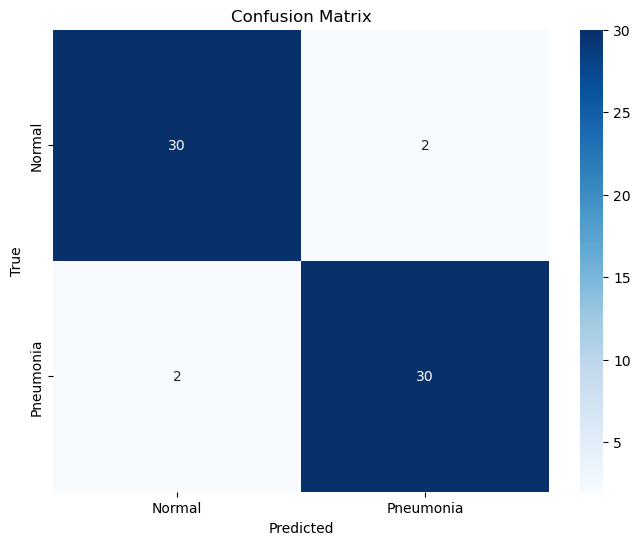

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(test_labels_vgg16, test_predictions)  # You can use any of the label variables

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


### Saving the model

In [ ]:
import joblib

# Save the AdaBoost classifier to a file
joblib.dump(ada_boost_classifier, 'ensemble_adaboost.pkl')
